# 🤖 Fase de modelado — Predicción de `tendencia_desempeno`
### Reto Analítica Educativa · Samsung Innovation Campus 2025 · equipo Tech Tailors

| | |
|---|---|
| Proyecto | Analítica Educativa — evaluaciones docentes |
| Notebook | 03 · Modelado de la tendencia de desempeño |
| Objetivo | Entrenar, validar, calibrar y exportar el modelo de tendencia |
| Entradas | data/processed/evaluaciones_con_sentimiento.csv |
| Salidas | analisis_datos/models/modelo_tendencia_docente.pkl + metadatos |
| Equipo | Tech Tailors |

Entrena y **produce el modelo** que clasifica cada evaluación docente en
`Mejora` / `Estable` / `En riesgo`, siguiendo las recomendaciones del informe de revisión:

1. **Features sin fuga ni redundancia** (se excluyen `delta_semestre`, `hist_prom_previo`,
   `id_docente`, `semestre`; ver §2).
2. **Cuatro candidatos**: regla de 2 umbrales, regla híbrida (+ sentimiento), Regresión
   Logística, RandomForest y Gradient Boosting.
3. **Dos protocolos de validación**: partición estratificada (con validación cruzada) y
   **validación temporal** (entrenar 2020–2022, probar 2023) — la prueba honesta de
   generalización.
4. **Métrica de negocio**: macro-F1 con **recall de `En riesgo` ≥ 0.985** como restricción dura.
5. **Calibración de probabilidades** del campeón (para priorizar docentes) y **exportación**
   del artefacto a disco (`.pkl`) + función de predicción.

> ⚠️ **Advertencia metodológica (del informe).** La etiqueta `tendencia_desempeno` está
> derivada por reglas y alineada con los puntajes y la polaridad de las 20 plantillas de
> comentario. Por eso cualquier modelo alcanza macro-F1 ≈ 0.90 y **la ventaja del ML sobre la
> regla no es estadísticamente significativa**. Estas métricas son un **techo artificial**;
> el valor real del pipeline debe validarse con datos y comentarios libres reales.


In [1]:
# --- Arranque: localizar la raíz del proyecto (para rutas e imports de src/) ---
import sys, pathlib
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / 'src').is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from src import rutas
print('Raíz del proyecto:', RAIZ)

Raíz del proyecto: /Users/nato/Documents/Analisis de sentimiento


## 0 · Preparación del entorno (autónomo)

Estas dos celdas hacen el notebook **ejecutable en cualquier entorno** (local o Google Colab)
sin pasos previos:
1. Instala las dependencias.
2. Localiza la raíz del repo y añade `src/` al path (celda de arranque) para importar
   `src.modelo_utils`, donde vive —versionado— el código del modelo.

Solo necesitas que el CSV de evaluaciones esté en la misma carpeta; si falta la columna de
sentimiento, se reconstruye desde el gold embebido en `modelo_utils.py`.

In [2]:
# 1) Dependencias (idempotente; en Colab instala, en local no hace nada si ya están)
import importlib, subprocess, sys
_faltan = [p for p in ['sklearn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'joblib']
           if importlib.util.find_spec(p) is None]
if _faltan:
    paquetes = {'sklearn': 'scikit-learn'}
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    *[paquetes.get(p, p) for p in _faltan]], check=True)
    print('Instalado:', _faltan)
else:
    print('Dependencias ya presentes.')

Dependencias ya presentes.


## 1 · Configuración

In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings
warnings.filterwarnings('ignore')

from sklearn.base import clone
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (f1_score, recall_score, accuracy_score,
                             classification_report, confusion_matrix, brier_score_loss)

from src.modelo_utils import (ReglaUmbrales, ClasificadorConUmbralRiesgo, umbral_para_recall,
                          construir_features, predecir_tendencia, CLASES)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

COLOR_TENDENCIA = {'Mejora': '#0ca30c', 'Estable': '#2a78d6', 'En riesgo': '#d03b3b'}
ORDEN = ['Mejora', 'Estable', 'En riesgo']
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#c3c2b7', 'axes.grid': True, 'grid.color': '#e1e0d9',
    'axes.axisbelow': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlecolor': INK,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'legend.frameon': False,
})
RECALL_MIN = 0.985   # restricción de negocio para 'En riesgo'
print('Entorno listo | semilla =', RANDOM_STATE, '| recall mínimo En riesgo =', RECALL_MIN)

Entorno listo | semilla = 42 | recall mínimo En riesgo = 0.985


## 2 · Datos y construcción de features

`cargar_dataset` encuentra el CSV (procesado o crudo) y **garantiza** la columna
`sentimiento_final` reconstruyéndola desde el gold embebido si hace falta. La función
`construir_features` documenta y aplica la selección de variables.

In [4]:
from src.modelo_utils import cargar_dataset
df, _origen = cargar_dataset()
print('Datos cargados desde:', _origen, '|', len(df), 'filas')
X = construir_features(df, columna_sentimiento='sentimiento_final')
y = df['tendencia_desempeno']

# Features que cada familia de modelo consume
NUM_ML = ['puntaje_claridad', 'puntaje_metodologia', 'puntaje_evaluacion',
          'numero_estudiantes', 'sentimiento_gold_score']   # ML: sin puntaje_promedio (redundante)
CAT_ML = ['asignatura']

print('Features disponibles:', list(X.columns))
print('ML numéricas:', NUM_ML, '| ML categóricas:', CAT_ML)
print('Regla usa: puntaje_promedio (+ sentimiento_gold_score en la variante híbrida)')
print()
print('Excluidas a propósito (informe de revisión):')
print('  delta_semestre  → fuga del semestre actual')
print('  hist_prom_previo, id_docente, semestre → sin poder predictivo / alta cardinalidad')
print()
print('Balance de clases:')
print((y.value_counts(normalize=True).reindex(ORDEN) * 100).round(1).astype(str) + ' %')
X.head()

Datos cargados desde: /Users/nato/Documents/Analisis de sentimiento/data/processed/evaluaciones_con_sentimiento.csv | 3000 filas
Features disponibles: ['puntaje_claridad', 'puntaje_metodologia', 'puntaje_evaluacion', 'puntaje_promedio', 'numero_estudiantes', 'sentimiento_gold_score', 'asignatura']
ML numéricas: ['puntaje_claridad', 'puntaje_metodologia', 'puntaje_evaluacion', 'numero_estudiantes', 'sentimiento_gold_score'] | ML categóricas: ['asignatura']
Regla usa: puntaje_promedio (+ sentimiento_gold_score en la variante híbrida)

Excluidas a propósito (informe de revisión):
  delta_semestre  → fuga del semestre actual
  hist_prom_previo, id_docente, semestre → sin poder predictivo / alta cardinalidad

Balance de clases:
tendencia_desempeno
Mejora       30.1 %
Estable      50.0 %
En riesgo    19.9 %
Name: proportion, dtype: str


,puntaje_claridad,puntaje_metodologia,puntaje_evaluacion,puntaje_promedio,numero_estudiantes,sentimiento_gold_score,asignatura
0,3.2,4.1,3.9,3.733333,38,0,Matemáticas Básicas
1,4.3,3.7,4.1,4.033333,38,1,Programación Orientada a Objetos
2,4.2,4.2,3.1,3.833333,33,1,Ingeniería de Software
3,5.0,4.2,4.6,4.600000,21,1,Matemáticas Básicas
4,4.1,3.7,4.1,3.966667,32,1,Estructuras de Datos


## 3 · Definición de candidatos

Cada modelo de ML va dentro de un `Pipeline` con su preprocesamiento (escalado + one-hot),
de modo que el artefacto final incluye toda la transformación y recibe datos crudos.

In [5]:
def preprocesador():
    return ColumnTransformer([
        ('num', StandardScaler(), NUM_ML),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_ML),
    ])

candidatos = {
    'Regla 2 umbrales': ReglaUmbrales(usar_sentimiento=False),
    'Regla híbrida (+sent)': ReglaUmbrales(usar_sentimiento=True),
    'Regresión logística': Pipeline([
        ('prep', preprocesador()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                   random_state=RANDOM_STATE))]),
    'RandomForest': Pipeline([
        ('prep', preprocesador()),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([
        ('prep', preprocesador()),
        ('clf', HistGradientBoostingClassifier(class_weight='balanced',
                                               random_state=RANDOM_STATE))]),
}
print('Candidatos:', list(candidatos.keys()))

Candidatos: ['Regla 2 umbrales', 'Regla híbrida (+sent)', 'Regresión logística', 'RandomForest', 'Gradient Boosting']


## 4 · Protocolo A — Partición estratificada + validación cruzada

Split 75/25 estratificado. En el conjunto de entrenamiento se hace **5-fold CV** (macro-F1)
para estimar la generalización; luego se evalúa en el test retenido.

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

filas = []
modelos_entrenados = {}
for nombre, modelo in candidatos.items():
    # CV solo para modelos con preprocesamiento sklearn (la regla no necesita CV de features)
    try:
        cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=cv, scoring='f1_macro', n_jobs=-1)
        cv_mean, cv_std = cv_scores.mean(), cv_scores.std()
    except Exception:
        cv_mean = cv_std = np.nan
    modelo.fit(X_tr, y_tr)
    modelos_entrenados[nombre] = modelo
    pred = modelo.predict(X_te)
    filas.append({
        'modelo': nombre,
        'CV macro-F1': f'{cv_mean:.3f} ± {cv_std:.3f}' if not np.isnan(cv_mean) else '—',
        'test macro-F1': round(f1_score(y_te, pred, average='macro'), 3),
        'test accuracy': round(accuracy_score(y_te, pred), 3),
        'recall En riesgo': round(recall_score(y_te, pred, labels=['En riesgo'], average=None)[0], 3),
        'cumple recall≥0.985': '✅' if recall_score(y_te, pred, labels=['En riesgo'], average=None)[0] >= RECALL_MIN else '❌',
    })
tabla_A = pd.DataFrame(filas).set_index('modelo')
tabla_A

,CV macro-F1,test macro-F1,test accuracy,recall En riesgo,cumple recall≥0.985
modelo,,,,,
Regla 2 umbrales,0.914 ± 0.003,0.904,0.896,0.953,❌
Regla híbrida (+sent),0.878 ± 0.009,0.889,0.881,0.953,❌
Regresión logística,0.916 ± 0.013,0.908,0.900,0.973,❌
RandomForest,0.910 ± 0.006,0.915,0.907,0.960,❌
Gradient Boosting,0.903 ± 0.011,0.910,0.903,0.960,❌


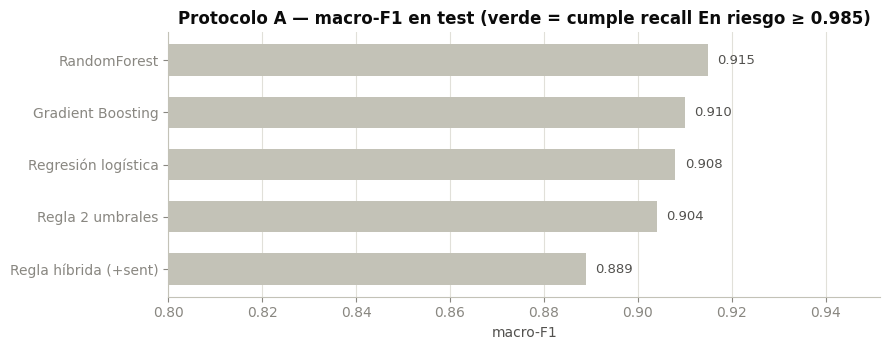

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.6))
f1s = tabla_A['test macro-F1'].sort_values()
colores = ['#0ca30c' if tabla_A.loc[m, 'cumple recall≥0.985'] == '✅' else '#c3c2b7' for m in f1s.index]
barras = ax.barh(f1s.index, f1s.values, color=colores, height=0.6)
for b, v in zip(barras, f1s.values):
    ax.text(v + 0.002, b.get_y() + b.get_height()/2, f'{v:.3f}', va='center', fontsize=9.5, color=INK2)
ax.set_xlim(0.8, f1s.max() * 1.04)
ax.set_title('Protocolo A — macro-F1 en test (verde = cumple recall En riesgo ≥ 0.985)')
ax.set_xlabel('macro-F1'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

## 5 · Protocolo B — Validación temporal (2020–2022 → 2023)

La prueba honesta de generalización: se entrena con los semestres 2020–2022 y se predice
2023, que el modelo nunca vio. Detecta si el desempeño del split aleatorio es optimista.

In [8]:
anio = df['semestre'].str[:4].astype(int)
tr_mask = (anio <= 2022).values
te_mask = (anio == 2023).values
Xtr_t, Xte_t = X[tr_mask], X[te_mask]
ytr_t, yte_t = y[tr_mask], y[te_mask]
print(f'Entrenamiento 2020–2022: {tr_mask.sum():,} filas | Prueba 2023: {te_mask.sum():,} filas')

filas_B = []
for nombre, modelo in candidatos.items():
    m = clone(candidatos[nombre])
    m.fit(Xtr_t, ytr_t)
    pred = m.predict(Xte_t)
    filas_B.append({
        'modelo': nombre,
        'macro-F1 2023': round(f1_score(yte_t, pred, average='macro'), 3),
        'accuracy 2023': round(accuracy_score(yte_t, pred), 3),
        'recall En riesgo 2023': round(recall_score(yte_t, pred, labels=['En riesgo'], average=None)[0], 3),
    })
tabla_B = pd.DataFrame(filas_B).set_index('modelo')
comparacion = tabla_A[['test macro-F1']].join(tabla_B[['macro-F1 2023']])
comparacion['Δ (temporal − aleatorio)'] = (comparacion['macro-F1 2023'] - comparacion['test macro-F1']).round(3)
print('Comparación de protocolos:')
comparacion

Entrenamiento 2020–2022: 2,265 filas | Prueba 2023: 735 filas


Comparación de protocolos:


,test macro-F1,macro-F1 2023,Δ (temporal − aleatorio)
modelo,,,
Regla 2 umbrales,0.904,0.907,0.003
Regla híbrida (+sent),0.889,0.890,0.001
Regresión logística,0.908,0.903,-0.005
RandomForest,0.915,0.905,-0.010
Gradient Boosting,0.910,0.894,-0.016


> 📌 **Lectura.** Si `macro-F1 2023` ≈ `test macro-F1`, el split aleatorio no era optimista
> (coherente con el Insight 6: no hay deriva temporal). Un Δ muy negativo indicaría
> sobreajuste al mezclar semestres del mismo docente en train y test.

## 6 · Selección del campeón

**Criterio:** entre los candidatos que cumplen `recall En riesgo ≥ 0.985`, el de mayor
macro-F1. **Desempate** (diferencias dentro del ruido, ver informe §3.3): se prefiere un
modelo **probabilístico** (da probabilidades calibrables para priorizar docentes) sobre una
regla dura.

In [9]:
probabilistico = {'Regresión logística', 'RandomForest', 'Gradient Boosting'}
cumplen = tabla_A['cumple recall≥0.985'] == '✅'
if cumplen.any():
    base = tabla_A[cumplen]
    print('Candidatos que cumplen recall En riesgo ≥ 0.985:', list(base.index))
else:
    base = tabla_A
    print(f'⚠️ NINGÚN candidato alcanza recall En riesgo ≥ {RECALL_MIN} con este set de '
          f'features (rango observado: {tabla_A["recall En riesgo"].min():.3f}–'
          f'{tabla_A["recall En riesgo"].max():.3f}).')
    print('   Se elige por macro-F1 y se documenta como PENDIENTE: para cerrar la brecha,')
    print('   bajar el umbral de decisión de la clase "En riesgo" (favorecer sensibilidad).')

tope = base['test macro-F1'].max()
cerca = base[base['test macro-F1'] >= tope - 0.01]           # dentro del ruido (~1 pto)
prob_cerca = [m for m in cerca.index if m in probabilistico]
campeon_nombre = (max(prob_cerca, key=lambda m: tabla_A.loc[m, 'test macro-F1'])
                  if prob_cerca else base['test macro-F1'].idxmax())

print(f'\nMejor macro-F1: {tope:.3f} | dentro del margen de ruido: {list(cerca.index)}')
print(f'Desempate → modelo probabilístico (probabilidades calibrables para priorizar docentes)')
print(f'\n🏆 CAMPEÓN: {campeon_nombre}')
print(f'   test macro-F1 = {tabla_A.loc[campeon_nombre, "test macro-F1"]} | '
      f'recall En riesgo = {tabla_A.loc[campeon_nombre, "recall En riesgo"]} | '
      f'macro-F1 2023 = {tabla_B.loc[campeon_nombre, "macro-F1 2023"]}')
campeon = modelos_entrenados[campeon_nombre]

⚠️ NINGÚN candidato alcanza recall En riesgo ≥ 0.985 con este set de features (rango observado: 0.953–0.973).
   Se elige por macro-F1 y se documenta como PENDIENTE: para cerrar la brecha,
   bajar el umbral de decisión de la clase "En riesgo" (favorecer sensibilidad).

Mejor macro-F1: 0.915 | dentro del margen de ruido: ['Regresión logística', 'RandomForest', 'Gradient Boosting']
Desempate → modelo probabilístico (probabilidades calibrables para priorizar docentes)

🏆 CAMPEÓN: RandomForest
   test macro-F1 = 0.915 | recall En riesgo = 0.96 | macro-F1 2023 = 0.905


## 7 · Diagnóstico del campeón

              precision    recall  f1-score   support

   En riesgo       0.98      0.96      0.97       149
     Estable       0.92      0.89      0.91       375
      Mejora       0.84      0.90      0.87       226

    accuracy                           0.91       750
   macro avg       0.91      0.92      0.91       750
weighted avg       0.91      0.91      0.91       750



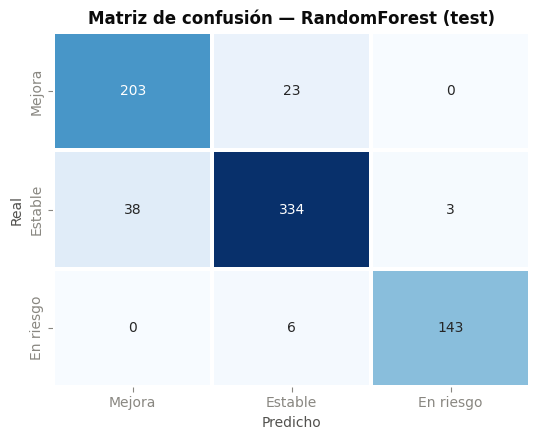

In [10]:
pred_te = campeon.predict(X_te)
print(classification_report(y_te, pred_te))

cm = confusion_matrix(y_te, pred_te, labels=ORDEN)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ORDEN, yticklabels=ORDEN,
            linewidths=1.5, linecolor='white', cbar=False, ax=ax)
ax.set_title(f'Matriz de confusión — {campeon_nombre} (test)')
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.tight_layout(); plt.show()

## 8 · Calibración de probabilidades y ajuste al recall de negocio

Dos pasos sobre el campeón (si es probabilístico):
1. **Calibración** isotónica (5-fold) para que `P(En riesgo)` sea fiable — base del tablero
   de priorización.
2. **Ajuste del umbral de decisión** de `En riesgo` para cumplir `recall ≥ 0.985`. El umbral
   se busca con **probabilidades fuera de muestra** (`cross_val_predict` sobre el train) para
   no mirar el test, y luego se evalúa en el test.

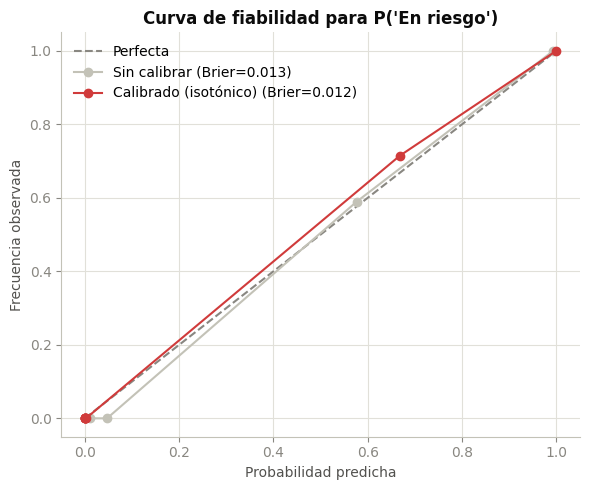

Umbral de decisión de "En riesgo" (OOF, objetivo recall≥0.985): 0.21
Brier sin/con calibración: 0.0133 / 0.0123
Recall En riesgo tras ajuste (test): 0.966 | macro-F1 tras ajuste (test): 0.899


In [11]:
if campeon_nombre in probabilistico:
    campeon_cal = CalibratedClassifierCV(campeon, method='isotonic', cv=5, ensemble=False).fit(X_tr, y_tr)
    idx = list(campeon.classes_).index('En riesgo')
    idx_c = list(campeon_cal.classes_).index('En riesgo')
    p_sin = campeon.predict_proba(X_te)[:, idx]
    p_con = campeon_cal.predict_proba(X_te)[:, idx_c]
    y_bin = (y_te == 'En riesgo').astype(int).values

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0, 1], [0, 1], '--', color=MUTED, label='Perfecta')
    for p, lbl, c in [(p_sin, 'Sin calibrar', '#c3c2b7'), (p_con, 'Calibrado (isotónico)', '#d03b3b')]:
        fx, fy = calibration_curve(y_bin, p, n_bins=8, strategy='quantile')
        ax.plot(fy, fx, marker='o', color=c, label=f'{lbl} (Brier={brier_score_loss(y_bin, p):.3f})')
    ax.set_title("Curva de fiabilidad para P('En riesgo')")
    ax.set_xlabel('Probabilidad predicha'); ax.set_ylabel('Frecuencia observada')
    ax.legend(); plt.tight_layout(); plt.show()

    # Umbral con probabilidades OOF del train (sin mirar test)
    p_oof = cross_val_predict(campeon_cal, X_tr, y_tr, cv=5, method='predict_proba')[:, idx_c]
    umbral = umbral_para_recall(y_tr, p_oof, objetivo=RECALL_MIN)
    modelo_final = ClasificadorConUmbralRiesgo(campeon_cal, umbral_riesgo=umbral).fit(X_tr, y_tr)
    pred_aj = modelo_final.predict(X_te)
    rec_aj = recall_score(y_te, pred_aj, labels=['En riesgo'], average=None)[0]
    print(f'Umbral de decisión de "En riesgo" (OOF, objetivo recall≥{RECALL_MIN}): {umbral}')
    print(f'Brier sin/con calibración: {brier_score_loss(y_bin, p_sin):.4f} / {brier_score_loss(y_bin, p_con):.4f}')
    print(f'Recall En riesgo tras ajuste (test): {rec_aj:.3f} | '
          f'macro-F1 tras ajuste (test): {f1_score(y_te, pred_aj, average="macro"):.3f}')
else:
    modelo_final = campeon
    umbral = None
    print('El campeón es una regla dura: no produce probabilidades calibrables ni admite '
          'ajuste de umbral. Se exporta tal cual.')

## 9 · Reentrenar en todos los datos y exportar el artefacto

El modelo de producción se reentrena con **el 100 % de los datos** (calibración + umbral
ajustado incluidos) y se guarda con `joblib`, junto a un JSON de metadatos.

In [12]:
# Reentrenar el campeón final sobre todo el dataset
if campeon_nombre in probabilistico:
    cal_full = CalibratedClassifierCV(clone(candidatos[campeon_nombre]), method='isotonic', cv=5, ensemble=False)
    modelo_produccion = ClasificadorConUmbralRiesgo(cal_full, umbral_riesgo=umbral).fit(X, y)
else:
    modelo_produccion = clone(candidatos[campeon_nombre]).fit(X, y)

RUTA_MODELO = str(rutas.dir_modelos() / 'modelo_tendencia_docente.pkl')
joblib.dump(modelo_produccion, RUTA_MODELO, compress=3)

metadatos = {
    'nombre_campeon': campeon_nombre,
    'clases': list(CLASES),
    'features_ml_numericas': NUM_ML,
    'features_ml_categoricas': CAT_ML,
    'sentimiento': 'gold (sentimiento_final), mapeo NEG=-1/NEU=0/POS=1',
    'metricas_test_aleatorio': {
        'macro_f1': float(tabla_A.loc[campeon_nombre, 'test macro-F1']),
        'recall_en_riesgo': float(tabla_A.loc[campeon_nombre, 'recall En riesgo']),
    },
    'metricas_temporal_2023': {
        'macro_f1': float(tabla_B.loc[campeon_nombre, 'macro-F1 2023']),
        'recall_en_riesgo': float(tabla_B.loc[campeon_nombre, 'recall En riesgo 2023']),
    },
    'calibrado': campeon_nombre in probabilistico,
    'umbral_en_riesgo': umbral,
    'objetivo_recall_en_riesgo': RECALL_MIN,
    'random_state': RANDOM_STATE,
    'advertencia': 'Etiqueta derivada por reglas y datos plantillados; metricas son techo artificial. Validar con datos reales.',
    'dependencia': 'requiere modelo_utils.py en el path para cargar el artefacto',
}
with open(rutas.dir_modelos() / 'modelo_tendencia_docente_metadatos.json', 'w', encoding='utf-8') as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

import os
print(f'✅ Modelo exportado: {RUTA_MODELO} ({os.path.getsize(RUTA_MODELO)/1024:.0f} KB)')
print('✅ Metadatos: modelo_tendencia_docente_metadatos.json')
print(json.dumps(metadatos, ensure_ascii=False, indent=2))

✅ Modelo exportado: /Users/nato/Documents/Analisis de sentimiento/analisis_datos/models/modelo_tendencia_docente.pkl (3520 KB)
✅ Metadatos: modelo_tendencia_docente_metadatos.json
{
  "nombre_campeon": "RandomForest",
  "clases": [
    "En riesgo",
    "Estable",
    "Mejora"
  ],
  "features_ml_numericas": [
    "puntaje_claridad",
    "puntaje_metodologia",
    "puntaje_evaluacion",
    "numero_estudiantes",
    "sentimiento_gold_score"
  ],
  "features_ml_categoricas": [
    "asignatura"
  ],
  "sentimiento": "gold (sentimiento_final), mapeo NEG=-1/NEU=0/POS=1",
  "metricas_test_aleatorio": {
    "macro_f1": 0.915,
    "recall_en_riesgo": 0.96
  },
  "metricas_temporal_2023": {
    "macro_f1": 0.905,
    "recall_en_riesgo": 0.993
  },
  "calibrado": true,
  "umbral_en_riesgo": 0.21,
  "objetivo_recall_en_riesgo": 0.985,
  "random_state": 42,
  "advertencia": "Etiqueta derivada por reglas y datos plantillados; metricas son techo artificial. Validar con datos reales.",
  "dependencia"

## 10 · Prueba del artefacto en producción

Recargamos el `.pkl` y predecimos casos nuevos con la función `predecir_tendencia`.

In [13]:
modelo_cargado = joblib.load(rutas.dir_modelos() / 'modelo_tendencia_docente.pkl')

ejemplos = [
    dict(puntaje_claridad=4.8, puntaje_metodologia=4.7, puntaje_evaluacion=4.6, sentimiento='POS'),
    dict(puntaje_claridad=2.1, puntaje_metodologia=2.4, puntaje_evaluacion=1.9, sentimiento='NEG'),
    dict(puntaje_claridad=3.6, puntaje_metodologia=3.8, puntaje_evaluacion=3.5, sentimiento='NEU'),
    dict(puntaje_claridad=4.0, puntaje_metodologia=3.9, puntaje_evaluacion=4.1, sentimiento='NEG'),
]
for e in ejemplos:
    clase, proba = predecir_tendencia(modelo_cargado, **e)
    print(f"claridad={e['puntaje_claridad']} metod={e['puntaje_metodologia']} "
          f"eval={e['puntaje_evaluacion']} sent={e['sentimiento']}  →  {clase}"
          + (f"   {proba}" if proba else ""))

claridad=4.8 metod=4.7 eval=4.6 sent=POS  →  Mejora   {'En riesgo': np.float64(0.001), 'Estable': np.float64(0.009), 'Mejora': np.float64(0.99)}
claridad=2.1 metod=2.4 eval=1.9 sent=NEG  →  En riesgo   {'En riesgo': np.float64(1.0), 'Estable': np.float64(0.0), 'Mejora': np.float64(0.0)}
claridad=3.6 metod=3.8 eval=3.5 sent=NEU  →  Estable   {'En riesgo': np.float64(0.001), 'Estable': np.float64(0.999), 'Mejora': np.float64(0.0)}
claridad=4.0 metod=3.9 eval=4.1 sent=NEG  →  Estable   {'En riesgo': np.float64(0.001), 'Estable': np.float64(0.978), 'Mejora': np.float64(0.021)}


## 11 · Conclusiones y entrega

- **Artefacto producido**: `modelo_tendencia_docente.pkl` (campeón reentrenado en el 100 % de
  los datos) + `modelo_tendencia_docente_metadatos.json`. Se carga con
  `joblib.load(...)` y requiere `modelo_utils.py` en el path.
- **Uso**: `predecir_tendencia(modelo, claridad, metodologia, evaluacion, sentimiento, ...)`
  devuelve la clase y —si el campeón es probabilístico— las probabilidades calibradas por clase,
  que son la base del tablero de priorización de docentes.
- **Validación**: se reporta partición aleatoria (con 5-fold CV) y validación temporal
  2020–2022→2023; ambas deben leerse contra la regla de 2 umbrales como baseline.

> ⚠️ **Recordatorio.** Sobre este dataset plantillado, macro-F1 ≈ 0.90 es un techo y la ventaja
> del ML sobre la regla no es significativa. Antes de desplegar: reentrenar con datos reales,
> sustituir la codificación de sentimiento por el pipeline transformer sobre comentarios
> libres, y re-medir con validación temporal y recall de `En riesgo` como restricción dura.

---
*Fase de modelado · equipo Tech Tailors · complementa el EDA y el informe de revisión.*